# Project 2: Predicting Student Dropouts

### What Non-GPA factors cause students to dropout? 

In [89]:
#import needed libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import tree 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [90]:
df = pd.read_csv("student_dropout_dataset_v3.csv")
df.set_index('Student_ID', inplace=True)
origin = df
df.head()

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
Student_ID,,,,,,,,,,,,,,,,,,
1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


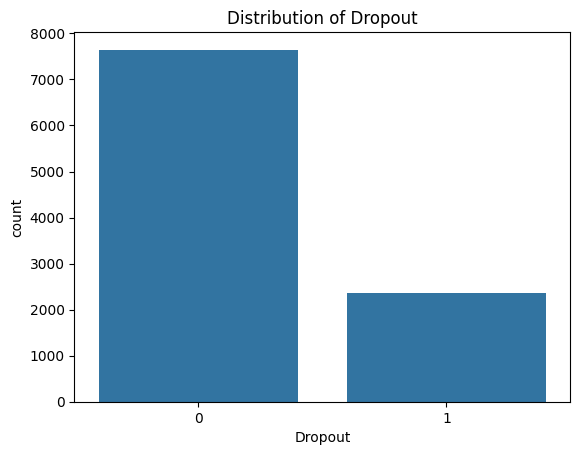

In [91]:
sns.countplot(x="Dropout", data=df)
plt.title("Distribution of Dropout")
plt.show()
#Close to 2,500 students dropped out, while around 7,500 students did not drop out. 
#This indicates that the majority of students in the dataset did not drop out, but there is still a significant portion that did.

## Data Processing 

In [92]:
for col in df.columns:
    print(f"{col}:\n {df[col].value_counts()}\n")

#All columns have atleast 2 unique values, so no columns can be dropped based on having only one unique value.

Age:
 Age
17.0    371
20.9    208
20.5    197
21.7    191
21.4    187
       ... 
28.0      1
28.1      1
29.6      1
28.8      1
28.4      1
Name: count, Length: 115, dtype: int64

Gender:
 Gender
Female    5011
Male      4989
Name: count, dtype: int64

Family_Income:
 Family_Income
25000.0    3668
37713.0       4
52974.0       3
53147.0       3
56345.0       3
           ... 
49322.0       1
42286.0       1
61103.0       1
40302.0       1
56894.0       1
Name: count, Length: 5438, dtype: int64

Internet_Access:
 Internet_Access
Yes    8769
No     1231
Name: count, dtype: int64

Study_Hours_per_Day:
 Study_Hours_per_Day
3.70    43
3.52    40
3.81    39
3.79    39
3.26    38
        ..
8.30     1
7.75     1
0.93     1
7.04     1
8.28     1
Name: count, Length: 702, dtype: int64

Attendance_Rate:
 Attendance_Rate
100.0    122
85.6      61
79.7      61
82.6      60
80.4      59
        ... 
60.1       1
61.7       1
62.4       1
57.3       1
52.9       1
Name: count, Length: 444, dtype: 

In [93]:
df.isna().sum()
#Missing values in Family_income, Parent_Education, Stress_Index, and Study_Hours

Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

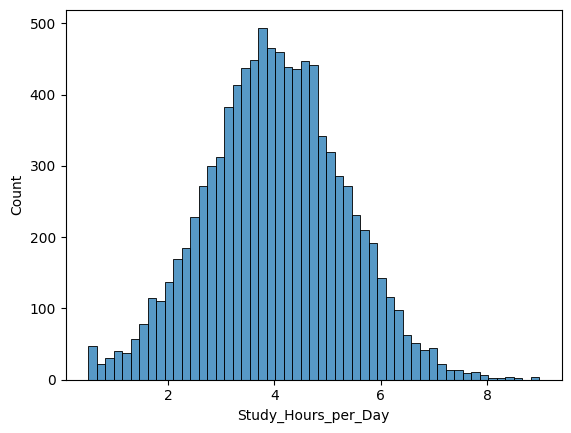

In [94]:
sns.histplot(data=df,x='Study_Hours_per_Day')
df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].mean(),inplace=True)
#Normal Distribution so we can fill the missing values with the mean.


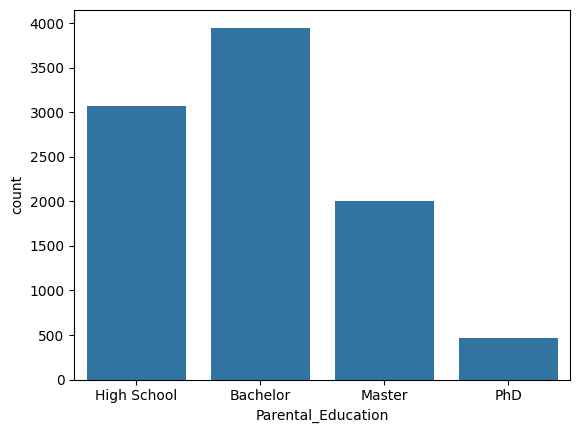

In [95]:
sns.countplot(data=df,x='Parental_Education')
#Since there is no valid way to fill in this data using central numbers we will drop all lines that are missing a parental education.
df = df.dropna()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\3143020991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Stress_Index'].fillna(df['Stress_Index'].mean(),inplace=True)


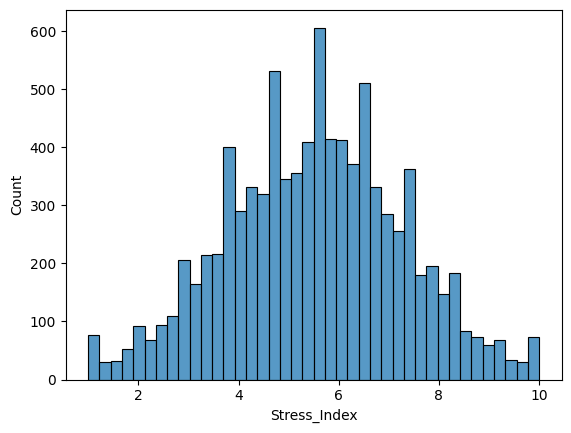

In [96]:
sns.histplot(data=df,x='Stress_Index')
df['Stress_Index'].fillna(df['Stress_Index'].mean(),inplace=True)
#Normal Distribution so we can use the mean in place of NaN values.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\3875469221.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\3875469221.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Family_Income'] = df['Family_Income']/10


<Axes: xlabel='Family_Income', ylabel='Count'>

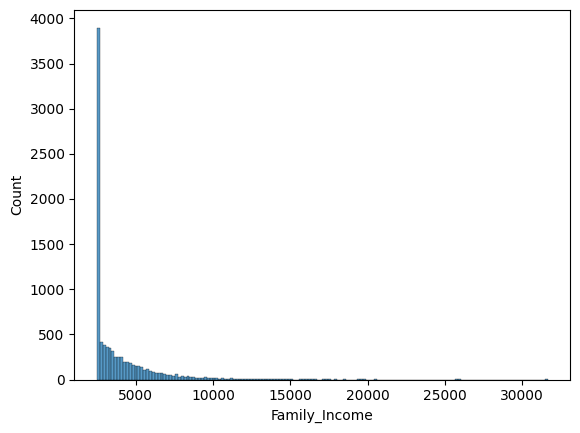

In [97]:
df['Family_Income'].fillna(df['Family_Income'].median(), inplace=True)
df['Family_Income'] = df['Family_Income']/10
sns.histplot(data=df,x='Family_Income')
#Family Income is a skewed distribution, so the median is a better measure of central tendency than the mean. 
#Family Income was also falsely reported and should be divided by 10 because it is monthly income and each value had a trailing zero.

### One Hot Encoding

In [98]:
df = pd.get_dummies(df,columns=['Gender','Internet_Access','Part_Time_Job','Scholarship','Semester','Parental_Education','Department'])
#Drop Extra Unneeded Columns
df.drop(columns=["Gender_Male","Internet_Access_No","Part_Time_Job_No","Scholarship_No"])
#This is better than using drop first as columns like Parental_Education_Bachelor would be removed from the dataset.

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Semester_Year 4,Parental_Education_Bachelor,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD,Department_Arts,Department_Business,Department_CS,Department_Engineering,Department_Science
Student_ID,,,,,,,,,,,,,,,,,,,,,
1,22.1,2500.0,3.36,86.1,2,20.4,5.5,0.96,0.90,0.90,...,False,False,True,False,False,True,False,False,False,False
2,20.7,2500.0,4.30,68.0,2,44.0,6.8,1.28,1.20,1.19,...,False,True,False,False,False,False,False,False,True,False
3,22.4,4018.3,4.40,70.9,0,48.9,5.5,1.68,1.32,1.32,...,False,False,False,True,False,True,False,False,False,False
5,20.5,2531.9,4.19,75.7,1,23.0,7.0,1.48,0.91,0.87,...,True,True,False,False,False,False,True,False,False,False
7,24.5,2500.0,3.00,78.2,1,37.4,7.3,0.64,0.33,0.44,...,True,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,23.9,4228.6,4.62,92.0,0,10.0,5.5,1.60,0.99,0.97,...,False,True,False,False,False,True,False,False,False,False
9997,17.0,6110.3,2.87,75.2,3,32.4,6.7,3.09,3.09,3.09,...,False,False,False,True,False,False,True,False,False,False
9998,19.4,2500.0,4.73,74.9,4,25.4,3.5,3.45,3.37,3.43,...,True,True,False,False,False,False,True,False,False,False


In [99]:
df.drop(columns=["GPA","Semester_GPA","CGPA"], inplace=True)

<Axes: xlabel='Family_Income', ylabel='Count'>

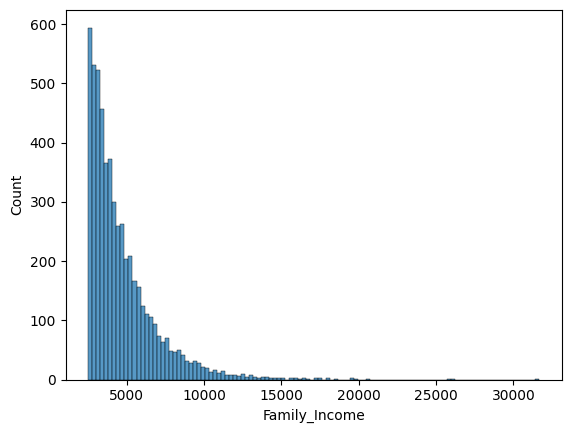

In [100]:
#This dataset is synthetic and for some reason has a lot of students with a family income of 2500, which is likely an error.
#The only way to fix this is to drop all students with a family income of 2500, which is 3,668 students.
#We will save this dataset so we can use it for a later model.
df_2500 = df
df = df[df['Family_Income'] != 2500]
sns.histplot(data=df,x='Family_Income')

In [101]:
df.isna().sum()
#Now that all missing values are taken care of and GPA is removed we can start working on the model.

Age                               0
Family_Income                     0
Study_Hours_per_Day               0
Attendance_Rate                   0
Assignment_Delay_Days             0
Travel_Time_Minutes               0
Stress_Index                      0
Dropout                           0
Gender_Female                     0
Gender_Male                       0
Internet_Access_No                0
Internet_Access_Yes               0
Part_Time_Job_No                  0
Part_Time_Job_Yes                 0
Scholarship_No                    0
Scholarship_Yes                   0
Semester_Year 1                   0
Semester_Year 2                   0
Semester_Year 3                   0
Semester_Year 4                   0
Parental_Education_Bachelor       0
Parental_Education_High School    0
Parental_Education_Master         0
Parental_Education_PhD            0
Department_Arts                   0
Department_Business               0
Department_CS                     0
Department_Engineering      

## Model 1

In [102]:
X = df.drop(columns="Dropout")
y = df["Dropout"]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=.2)
#Split the data set to create a test and training data set to test the accuracy of the model afterwards

In [104]:
clf = tree.DecisionTreeClassifier()
#Intiate Tree Classifier

In [105]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

X_train (4429, 28)
X_test (1108, 28)
y_train (4429,)
y_test (1108,)


In [106]:
clf = clf.fit(X_train,y_train)
#fit the model to the training data

In [107]:
clf.score(X_test,y_test)
#test accuracy of the model.

0.6850180505415162

### White box model

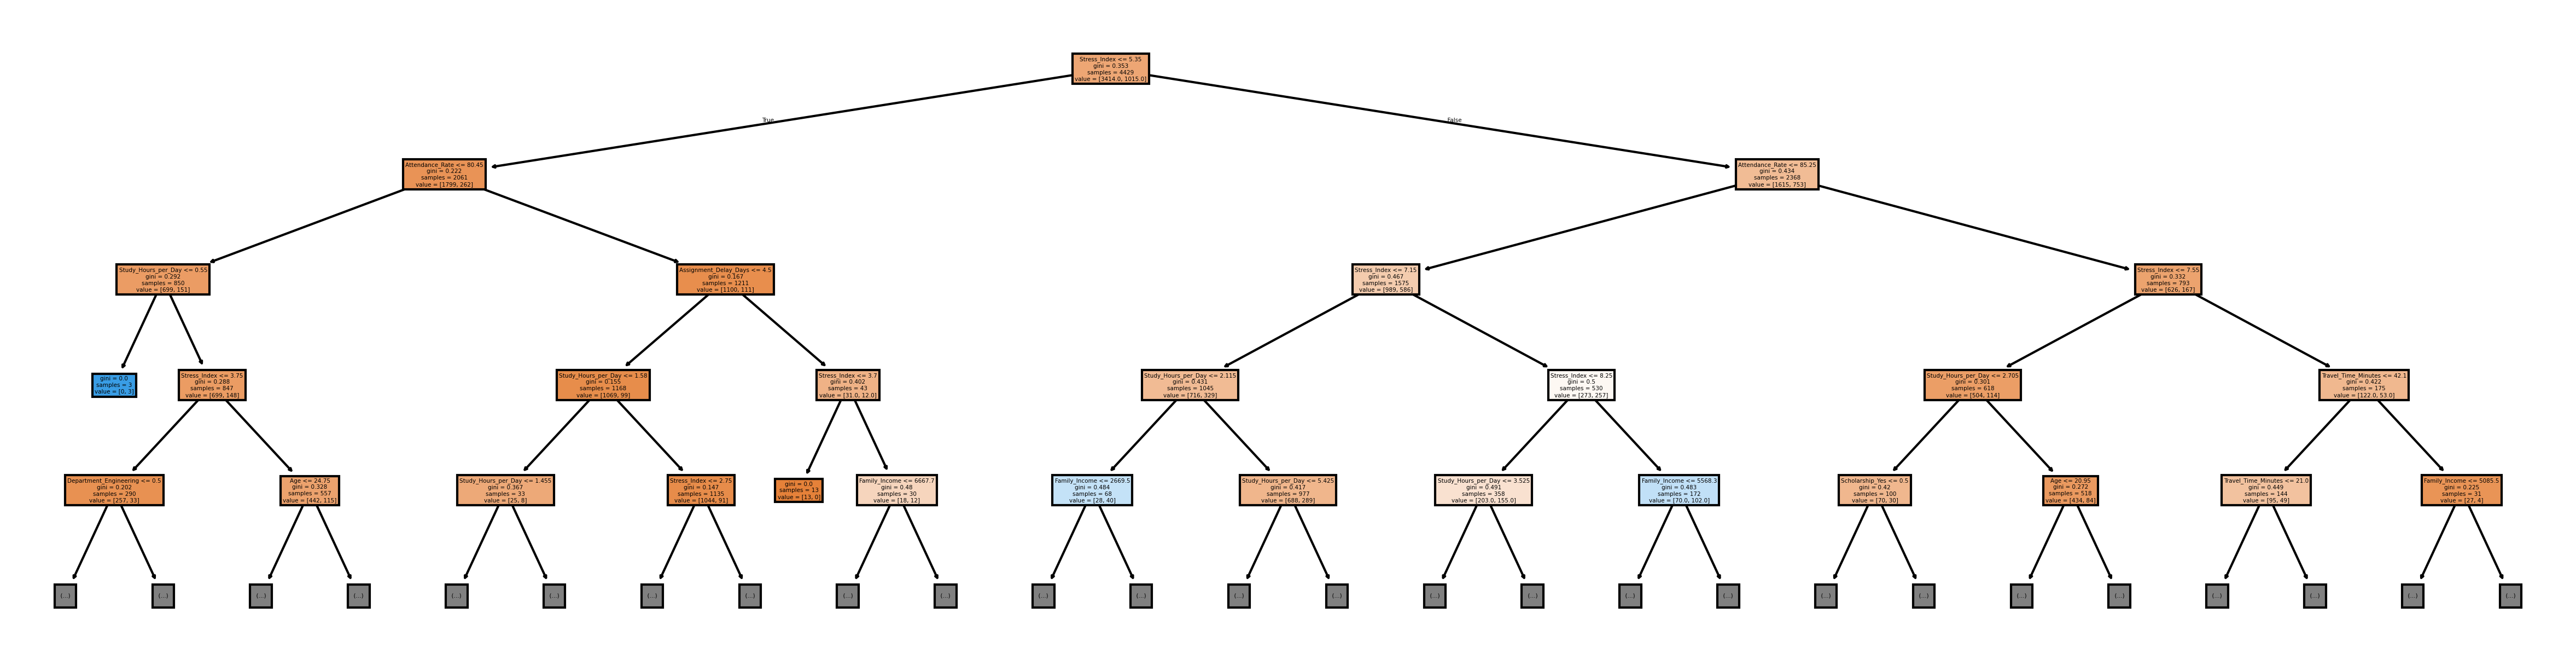

In [108]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (20,5), dpi=300)
tree.plot_tree(clf, max_depth = 4, feature_names = X.columns, filled=True)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\89601569.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


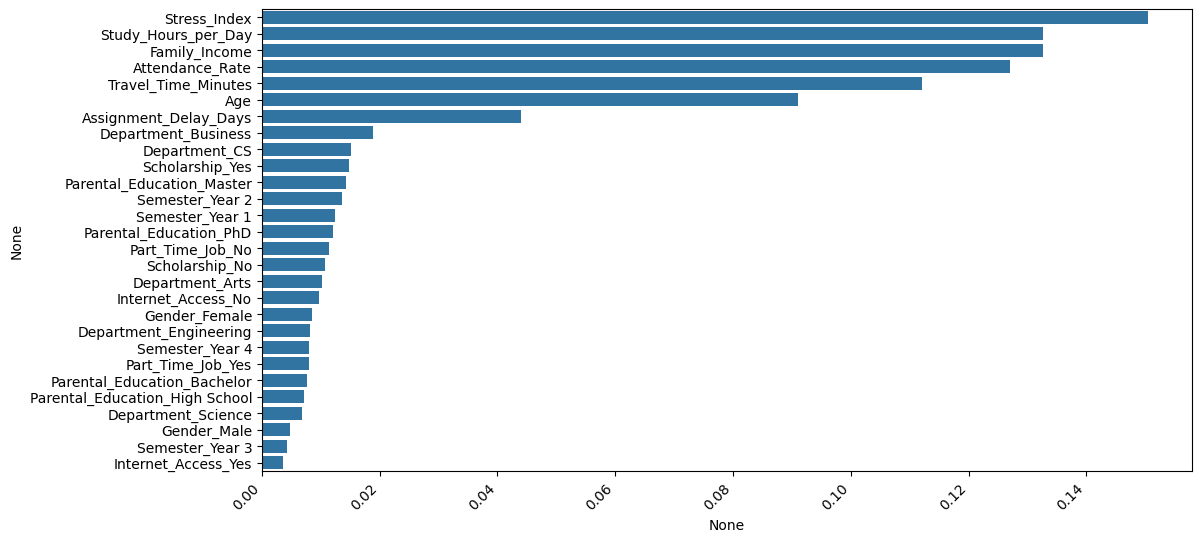

In [109]:
fi = clf.feature_importances_ #feature importance array
fi = pd.Series(data = fi, index = X.columns) #convert to Pandas series for plotting
fi.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi, y=fi.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

#### Model 2 (No Stress Index)

In [110]:
df2 = df
df2.drop(columns=["Stress_Index"], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\421739578.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.drop(columns=["Stress_Index"], inplace=True)


In [111]:
X2 = df2.drop(columns="Dropout")
y2 = df2["Dropout"]

In [112]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2, test_size=.2)

In [113]:
print("X2_train", X2_train.shape)
print("X2_test", X2_test.shape)
print("y2_train", y2_train.shape)
print("y2_test", y2_test.shape)

X2_train (4429, 27)
X2_test (1108, 27)
y2_train (4429,)
y2_test (1108,)


In [114]:
clf2 = tree.DecisionTreeClassifier()
clf2 = clf2.fit(X2_train,y2_train)

In [115]:
clf2.score(X2_test,y2_test)

0.6597472924187726

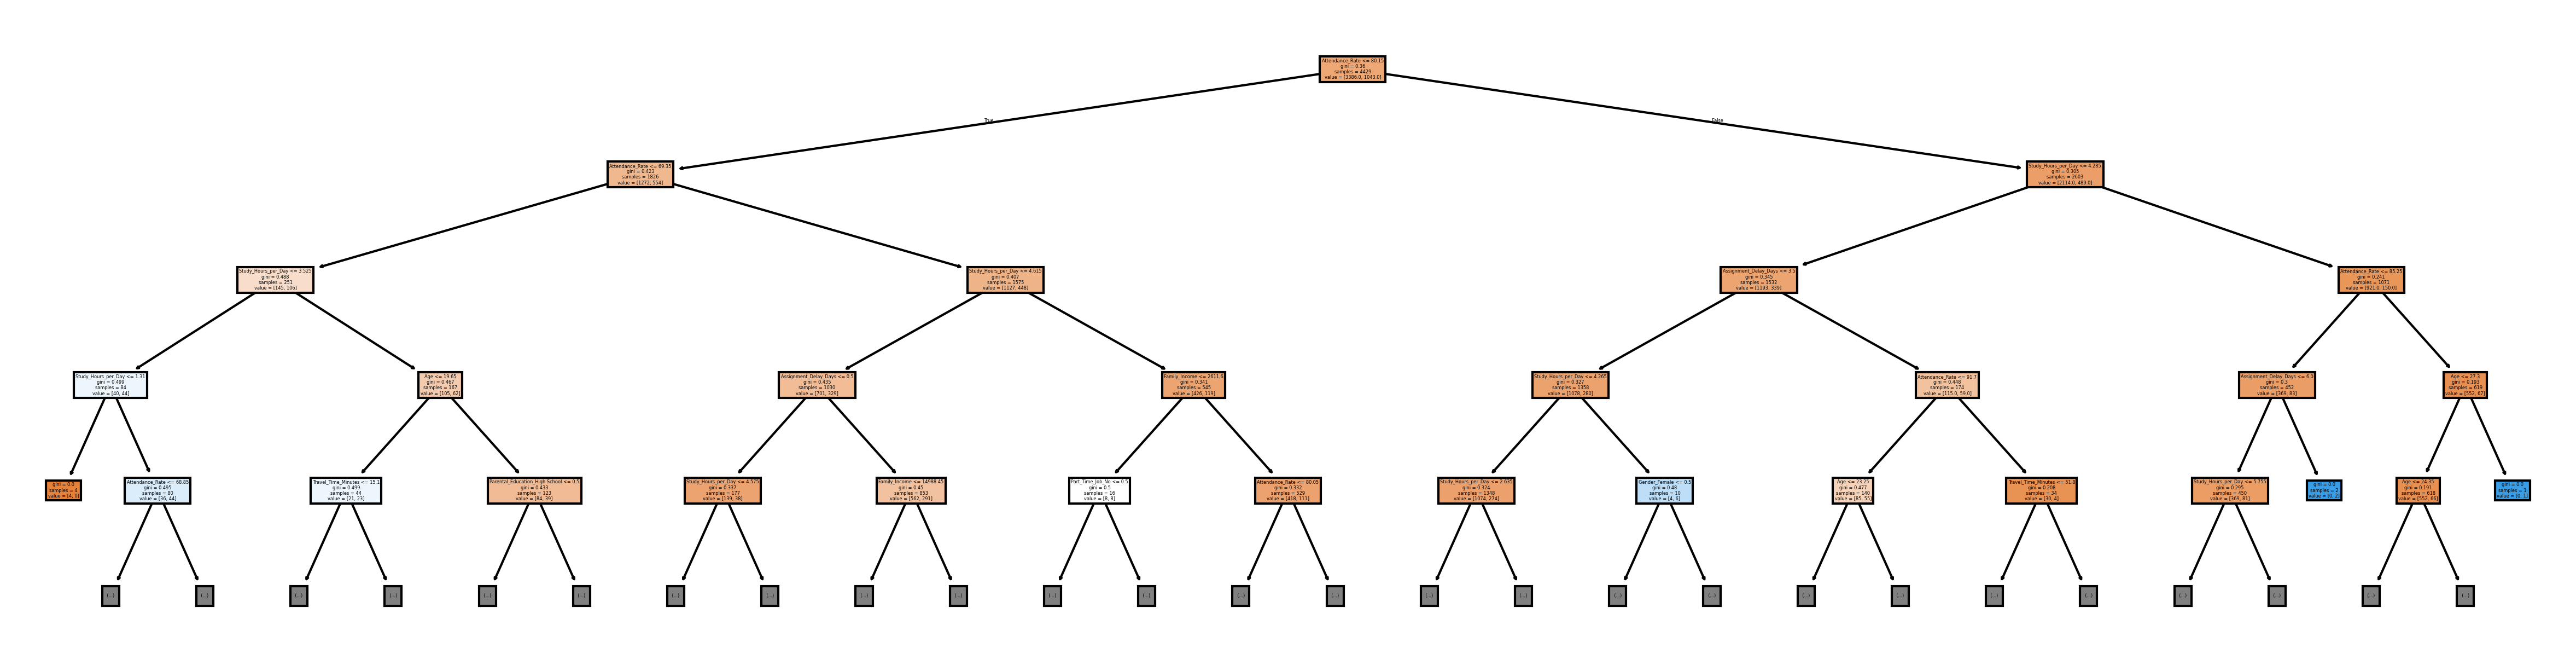

In [116]:
fig, axes = plt.subplots(nrows = 1,ncols = 1, figsize = (20,5), dpi=300)
tree.plot_tree(clf2, max_depth = 4, feature_names = X2.columns, filled=True)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\2215120876.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


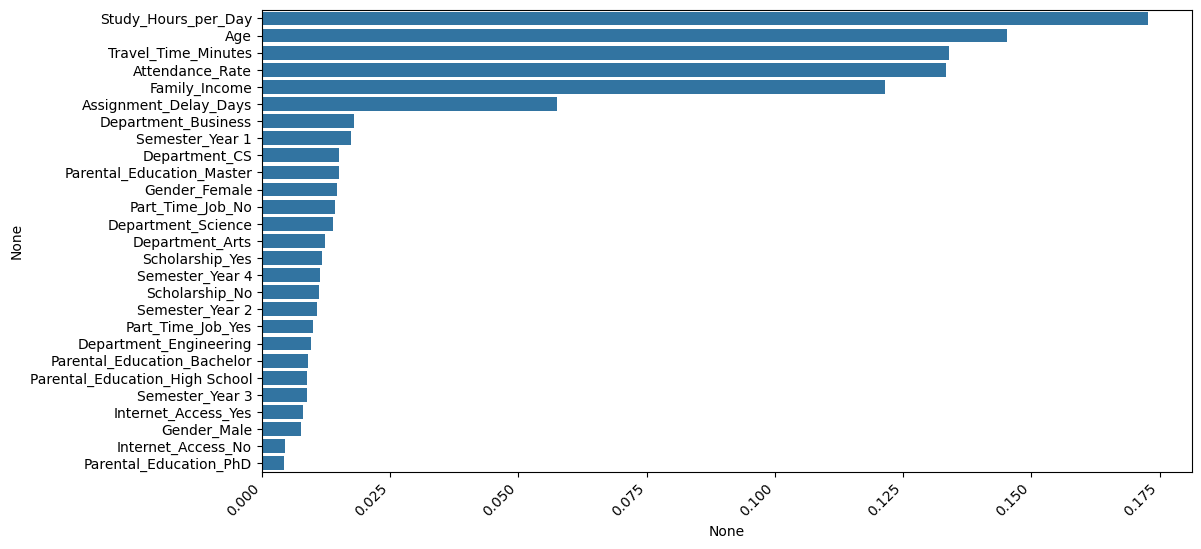

In [117]:
fi2 = clf2.feature_importances_ #feature importance array
fi2 = pd.Series(data = fi2, index = X2.columns) #convert to Pandas series for plotting
fi2.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi2, y=fi2.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()

6 Major factors determine if a student will drop out. Attendance, Age, Stress, Travel Time, Family Income and Study Hours.

#### Model 3 (Without removing the Family Income = 2500)

In [118]:
#Set df3 to the unedited dataset so that we can use it for the next model.
#This is a good model to create to see if the removal of students with a family income of 2500 are affecting the results of the model.
df3 = df_2500

In [119]:
X3 = df3.drop(columns="Dropout")
y3 = df3["Dropout"]

In [120]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3, test_size=.2)

In [121]:
print("X_train", X3_train.shape)
print("X_test", X3_test.shape)
print("y_train", y3_train.shape)
print("y_test", y3_test.shape)

X_train (7216, 28)
X_test (1804, 28)
y_train (7216,)
y_test (1804,)


In [122]:
clf3 = tree.DecisionTreeClassifier()
clf3 = clf3.fit(X3_train,y3_train)
clf3.score(X3_test,y3_test)

0.6856984478935698

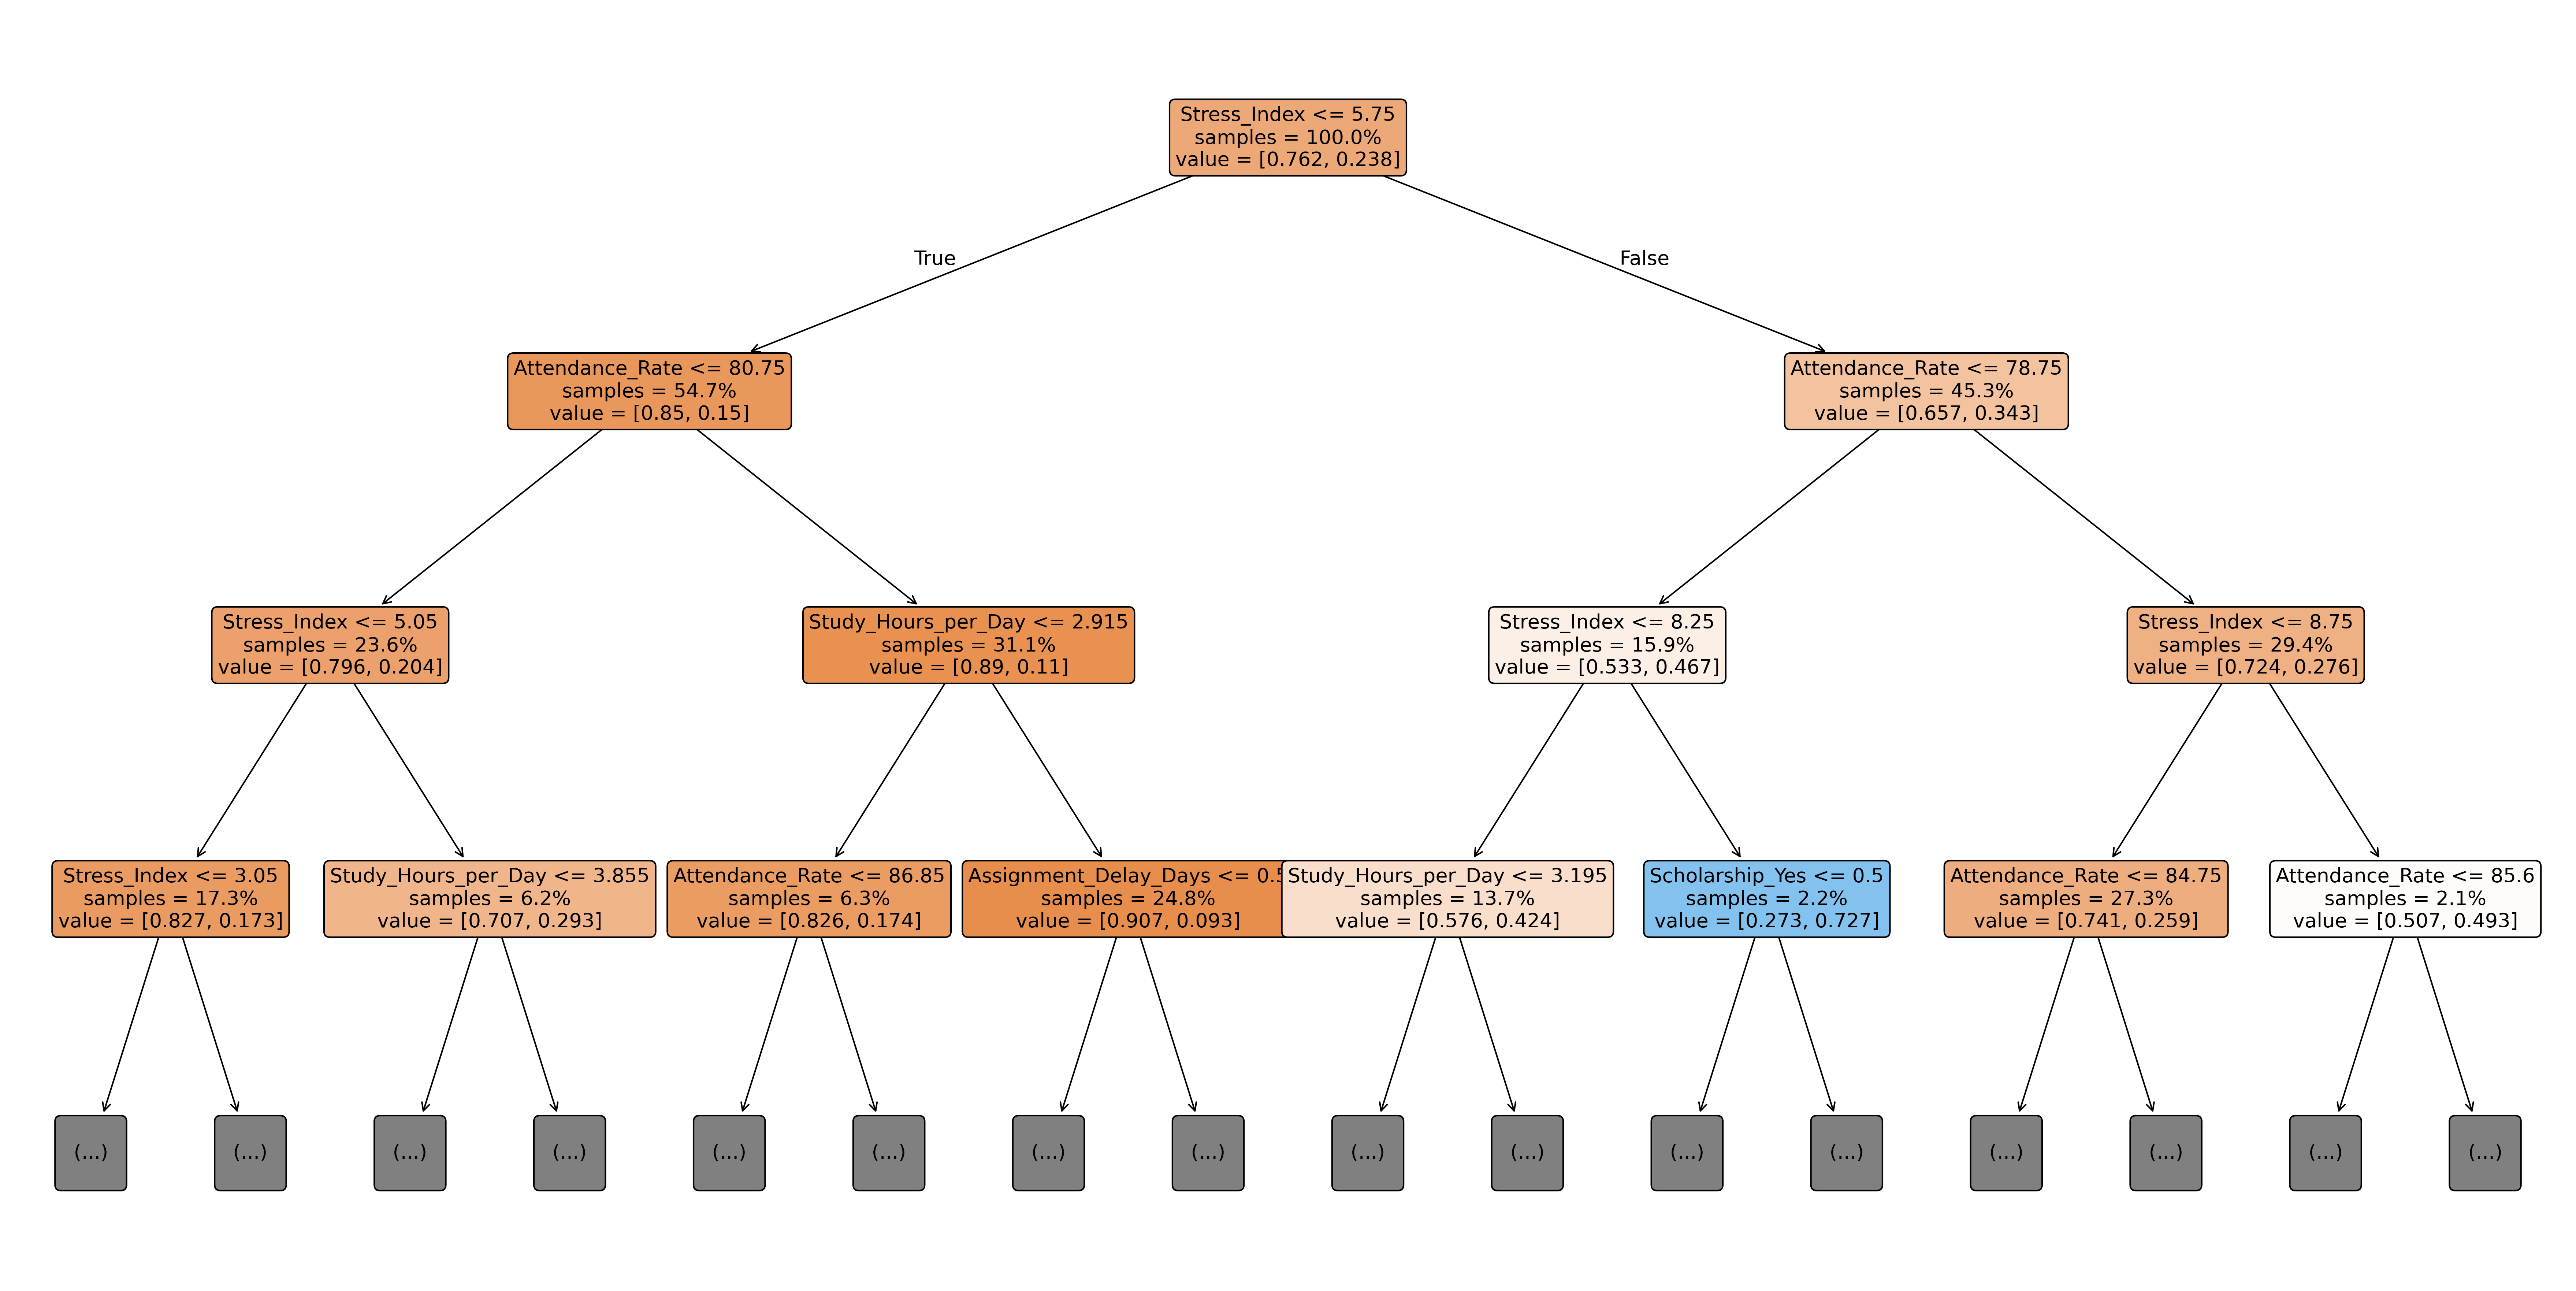

In [123]:
fig, axes = plt.subplots(figsize=(30, 15), dpi=300)

tree.plot_tree(
    clf3,
    max_depth=3,
    feature_names=X3.columns,
    filled=True,
    rounded=True,
    fontsize=13,
    impurity=False,
    proportion=True
)

plt.savefig("decision_tree.png", bbox_inches='tight')
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11356\3777899687.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')


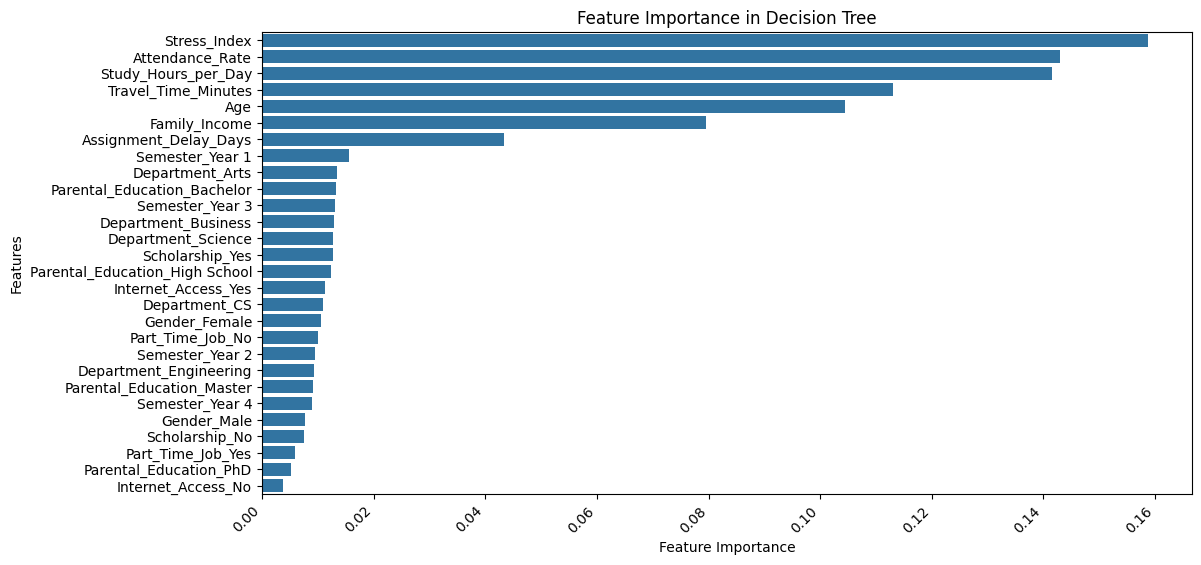

In [124]:
fi3 = clf3.feature_importances_ #feature importance array
fi3 = pd.Series(data = fi3, index = X3.columns) #convert to Pandas series for plotting
fi3.sort_values(ascending=False, inplace=True) #sort descending
#create bar plot
plt.figure(figsize=(12, 6))
chart = sns.barplot(x=fi3, y=fi3.index)
chart.set_xticklabels(chart.get_xticklabels(), rotation=45, horizontalalignment='right')
xlabel = "Feature Importance"
plt.xlabel(xlabel)
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree")
plt.show()

### Confusion Matrixes

In [125]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

We will make a confusion matrix to test for potential false positives and negatives and compare it to the other models.

In [126]:
y3_pred = clf3.predict(X3_test)
y2_pred = clf2.predict(X2_test)
y_pred = clf.predict(X_test)

In [127]:
cm = confusion_matrix(y_test, y_pred)
cm2 = confusion_matrix(y2_test, y2_pred)
cm3 = confusion_matrix(y3_test, y3_pred)
#Confusion matrix for model 3 will have more total values than model 1 and 2 because it has more data, but the ratio of true positives to 
# false positives and true negatives to false negatives is what we are looking at when comparing the models.
print(f"Model 1: {cm}")
print(f"Model 2: {cm2}")
print(f"Model 3: {cm3}")

Model 1: [[667 179]
 [170  92]]
Model 2: [[651 223]
 [154  80]]
Model 3: [[1101  299]
 [ 268  136]]


### Comparisons


In [128]:
scores1 = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
scores2 = cross_val_score(clf2, X2, y2, cv=5, scoring="accuracy")
scores3 = cross_val_score(clf3, X3, y3, cv=5, scoring="accuracy")
print(f"Model 1 cross validated scores: {scores1}")
print(f"Model 2 cross validated scores: {scores2}")
print(f"Model 3 cross validated scores: {scores3}")
print(f"Model 1 average cross validated score: {np.mean(scores1)}")
print(f"Model 2 average cross validated score: {np.mean(scores2)}")
print(f"Model 3 average cross validated score: {np.mean(scores3)}")

Model 1 cross validated scores: [0.69043321 0.66606498 0.6630533  0.67750678 0.67750678]
Model 2 cross validated scores: [0.6534296  0.62184116 0.6567299  0.64498645 0.63504968]
Model 3 cross validated scores: [0.67128603 0.67682927 0.65521064 0.67849224 0.672949  ]
Model 1 average cross validated score: 0.6749130084561977
Model 2 average cross validated score: 0.6424073584899507
Model 3 average cross validated score: 0.6709534368070953


In [129]:
recall1 = cross_val_score(clf, X, y, cv=5, scoring="recall")
recall2 = cross_val_score(clf2, X2, y2, cv=5, scoring="recall")
recall3 = cross_val_score(clf3, X3, y3, cv=5, scoring="recall")
print(f"Model 1 cross validated recall scores: {recall1}")
print(f"Model 2 cross validated recall scores: {recall2}")
print(f"Model 3 cross validated recall scores: {recall3}")
print(f"Model 1 average cross validated recall score: {np.mean(recall1)}")
print(f"Model 2 average cross validated recall score: {np.mean(recall2)}")
print(f"Model 3 average cross validated recall score: {np.mean(recall3)}")

Model 1 cross validated recall scores: [0.3359375  0.34765625 0.31764706 0.34509804 0.31372549]
Model 2 cross validated recall scores: [0.234375   0.22265625 0.38431373 0.34509804 0.29019608]
Model 3 cross validated recall scores: [0.33333333 0.37115839 0.31367925 0.37264151 0.36084906]
Model 1 average cross validated recall score: 0.3320128676470588
Model 2 average cross validated recall score: 0.295327818627451
Model 3 average cross validated recall score: 0.35033230741781524


In [144]:
precision1 = cross_val_score(clf, X, y, cv=5, scoring="precision")
precision2 = cross_val_score(clf2, X2, y2, cv=5, scoring="precision")
precision3 = cross_val_score(clf3, X3, y3, cv=5, scoring="precision")
print(f"Model 1 cross validated precision scores: {precision1}")
print(f"Model 2 cross validated precision scores: {precision2}")
print(f"Model 3 cross validated precision scores: {precision3}")
print(f"Model 1 average cross validated precision score: {np.mean(precision1)}")
print(f"Model 2 average cross validated precision score: {np.mean(precision2)}")
print(f"Model 3 average cross validated precision score: {np.mean(precision3)}")

Model 1 cross validated precision scores: [0.33203125 0.32013201 0.27364865 0.3125     0.30656934]
Model 2 cross validated precision scores: [0.24535316 0.20664207 0.29192547 0.26804124 0.25732899]
Model 3 cross validated precision scores: [0.31304348 0.31340206 0.28784648 0.33884298 0.33333333]
Model 1 average cross validated precision score: 0.30897625098313247
Model 2 average cross validated precision score: 0.2538581838903779
Model 3 average cross validated precision score: 0.3172936661065634


Surprisingly Model three is the most accurate of the three models prediciting the least false positives and false negatives while still predicting a solid amount of true positives. This would mean removing the 3,300 students did affect the accuracy of the dataset and it is still able to predict the same amount of true positives while predicting less false predictions. It also shows that removing stress index makes it harder for the model predict the correct result. Using these 2 findings we learn that model 3 is the most accurate model for predicting if a student will dropout.

In [131]:
depths = [5,10,20,30,40,50,80,100,200,500,1000,None]
for depth in depths:
    model = tree.DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores1 = cross_val_score(model, X, y, cv=5, scoring="recall")
    print(f"max_depth={depth} --> recall score: {scores1.mean():.4f}")

max_depth=5 --> recall score: 0.1386
max_depth=10 --> recall score: 0.2365
max_depth=20 --> recall score: 0.3257
max_depth=30 --> recall score: 0.3383
max_depth=40 --> recall score: 0.3438
max_depth=50 --> recall score: 0.3367
max_depth=80 --> recall score: 0.3328
max_depth=100 --> recall score: 0.3422
max_depth=200 --> recall score: 0.3375
max_depth=500 --> recall score: 0.3477
max_depth=1000 --> recall score: 0.3438
max_depth=None --> recall score: 0.3399


In [132]:
depths = [5,10,20,30,40,50,80,100,200,500,1000,None]
for depth in depths:
    model2 = tree.DecisionTreeClassifier(max_depth=depth)
    model2.fit(X2_train, y2_train)
    y2_pred = model2.predict(X2_test)
    scores2 = cross_val_score(model2, X2, y2, cv=5, scoring="recall")
    print(f"max_depth={depth} --> recall score: {scores2.mean():.4f}")

max_depth=5 --> recall score: 0.0282
max_depth=10 --> recall score: 0.1473
max_depth=20 --> recall score: 0.2788
max_depth=30 --> recall score: 0.3039
max_depth=40 --> recall score: 0.2945
max_depth=50 --> recall score: 0.3039
max_depth=80 --> recall score: 0.3063
max_depth=100 --> recall score: 0.2969
max_depth=200 --> recall score: 0.2961
max_depth=500 --> recall score: 0.3016
max_depth=1000 --> recall score: 0.2906
max_depth=None --> recall score: 0.2945


In [133]:
depths = [5,10,20,30,40,50,80,100,200,500,1000,None]
for depth in depths:
    model3 = tree.DecisionTreeClassifier(max_depth=depth)
    model3.fit(X3_train, y3_train)
    y3_pred = model3.predict(X3_test)
    scores3 = cross_val_score(model3, X3, y3, cv=5, scoring="recall")
    print(f"max_depth={depth} --> recall score: {scores3.mean():.4f}")

max_depth=5 --> recall score: 0.1440
max_depth=10 --> recall score: 0.2450
max_depth=20 --> recall score: 0.3409
max_depth=30 --> recall score: 0.3598
max_depth=40 --> recall score: 0.3527
max_depth=50 --> recall score: 0.3513
max_depth=80 --> recall score: 0.3503
max_depth=100 --> recall score: 0.3480
max_depth=200 --> recall score: 0.3456
max_depth=500 --> recall score: 0.3551
max_depth=1000 --> recall score: 0.3395
max_depth=None --> recall score: 0.3517


Changing the max depth has little effect on the recall score meaning that there doesn't need to be a set max depth to increase recall score.

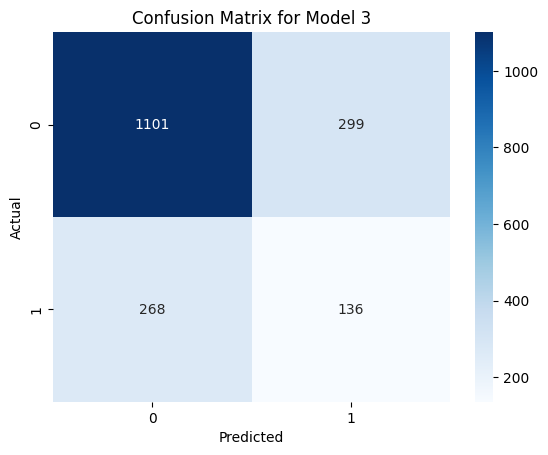

In [134]:
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Model 3")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This Visualization shows how many false prediction Model 3 is making compared to correct predictions.

## Final Conclusion

In conclusion there are 6 major non GPA factors that affects if a student will dropout. Those 6 being Age, Attendance, Study hours per day, Travel Time, and Family Income. All three models used these factors the most when prediciting if a student would drop out or not. I was surprised to find out that the most accurate model was actually the model that kept the 3,000 students that all had 2500 montly family income. This was surprising to me as I thought the large input of the same income would create a bias. If I were to do this project again I would pick a different dataset that wasn't synthetically created as there was a lot of data processing I had to do and make decisions about what the creator meant. I proved that my decision to remove the 3000 students was not the correct decision and hopefully wouldn't have to deal with that with a dataset that contained the data from actual students. Also the low recall score and accuracy score mean these models shouldn't be fully trusted for predicting if a student will dropout.